In [3]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


In [4]:
# Generate data
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
df = pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])

In [5]:
df.head()

,Feature 1,Feature 2
0,0.836857,2.136359
1,-1.413658,7.409623
2,1.155213,5.099619
3,-1.018616,7.814915
4,1.271351,1.892542


<Axes: >

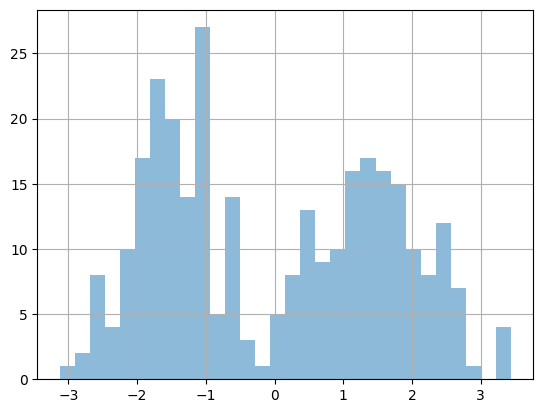

In [6]:
df['Feature 1'].hist(bins=30, alpha=0.5, label='Feature 1')

In [7]:
# Preprocessing: scale the features, since kmeans relies on distance metrics, and we want to ensure that all features contribute equally to the distance calculations.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [ ]:
inertia = [] # sum of squared distances of samples to their cluster center, also known as within-cluster sum of squares (WCSS)
k_values = range(2, 12)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [10]:
for k, i in zip(k_values, inertia):
    print(f"k={k}, inertia={i:.2f}")

k=2, inertia=270.34
k=3, inertia=139.35
k=4, inertia=56.02
k=5, inertia=48.60
k=6, inertia=42.03
k=7, inertia=40.24
k=8, inertia=34.28
k=9, inertia=32.03
k=10, inertia=25.66
k=11, inertia=24.05


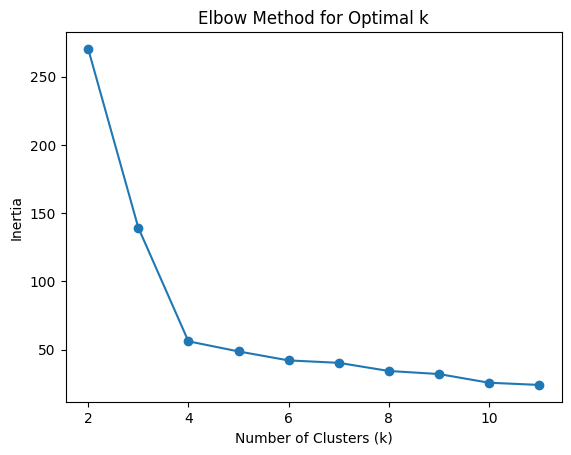

In [ ]:
# Elbow plot for selecting k value
plt.plot(k_values, inertia, marker='o') # elbow point is where the inertia starts to decrease at a slower rate, indicating that adding more clusters does not significantly improve the model.
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

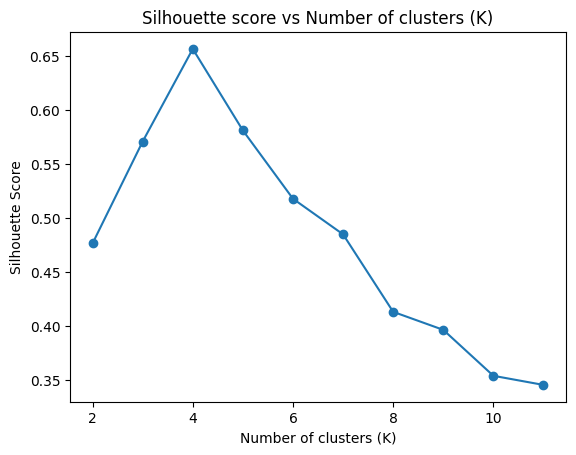

In [ ]:
# Silhouette score for evaluating clustering quality
silhouette_scores = [] # best silhouette score => best clustering quality
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_scaled, labels)
    silhouette_scores.append(silhouette_avg)

plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette score vs Number of clusters (K)")
plt.show()

In [16]:
# chosen optimal k
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=0)
kmeans.fit(X_scaled)

df['Cluster'] = kmeans.labels_

In [17]:
df

,Feature 1,Feature 2,Cluster
0,0.836857,2.136359,2
1,-1.413658,7.409623,3
2,1.155213,5.099619,0
3,-1.018616,7.814915,3
4,1.271351,1.892542,2
...,...,...,...
295,1.973698,1.579798,2
296,2.518342,1.391766,2
297,0.438990,4.535929,0
298,0.369479,7.791105,3


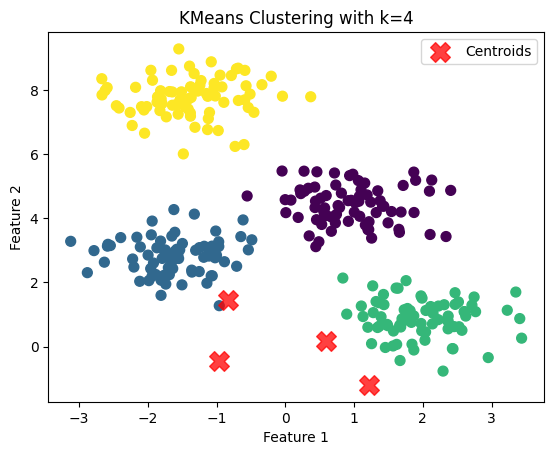

In [18]:
# Visualise clusters
plt.scatter(df['Feature 1'], df['Feature 2'], c=df['Cluster'], s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KMeans Clustering with k=4')
plt.legend()
plt.show()